#### Introducción
El propósito principal de este notebook es auditar y limpiar la calidad de los datos, además de realizar un Análisis Exploratorio de Datos (EDA).

Autores: David Ramírez, Octavio Chávez y Felipe Huincaman.

#### Requisitos de Software
Para la correcta ejecución del código en este notebook, se requiere un entorno de Python con las siguientes librerías instaladas:  
- Manejo y análisis de datos: pandas, numpy y scipy
- Visualización: matplotlib y seaborn
- Preprocesamiento y Machine Learning: scikit-learn

#### Importación de librerías necesarias

In [1]:
%pip install kneed

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\huinc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
import hashlib

import scipy.stats as ss

#### Carga de Data

In [3]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset_crudo.csv")

#### Información inicial de Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

# Manipulación de Datos

In [7]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [8]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [9]:
# convertir SeniorCitizen a object para que sea categórico
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: '0', 1: '1'}).astype(object)
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [10]:
# información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

* La variable objetivo que guiará nuestra exploración es el **Churn**.

#### Implementación de Anonimización

* De acuerdo con la legislación sobre protección de la vida privada, almacenar de forma directa el ID del cliente (CustomerID) junto con su comportamiento financiero expone a la empresa a severas multas.

In [11]:
def anonimizar(texto):
    # Genera un Hash único para el nombre (Irreversible)
    return hashlib.sha256(texto.encode()).hexdigest()

# Aplicar a la columna sensible
df['customerID_Hash'] = df['customerID'].apply(anonimizar)

# Eliminar el dato original
df.drop('customerID', axis=1, inplace=True)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,f3f9002e121cbbcc038f195a656a32a17395c6ce1815e8...
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5f362546eb7515f442a40d3d9bf632e4a481c92bcb0529...
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,701bf78bdf332d16ec5fb80a1affac3a080a8b9c258c2d...
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,59a0e1b332a6b6ba8f6a72f74085e6498e8c54a5d18191...
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,66370db9e1bb6a851fa692a2499f4f1356efab8e5abf90...


# Análisis Exploratorio de Datos

#### Análisis de completitud

In [13]:
# conteo de valores nulos por columna
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
customerID_Hash      0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [14]:
# muestra registros con valores nulos en TotalCharges
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,3fc827a9c771a5597e1b9563ba46bd77b5a33daad5f094...
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,cc8dcc067e61d7292f35e1d99cf280c8f1663b1d6b9dc0...
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,58d283200bed248b5d1e0eb621b905ecbb502854900fb3...
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,ea0b24cc08647ff604fd33a68453a8adb51fdc83f96386...
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0e9341d2f088bdb7928f46db857c21c35c9eaafb56084d...
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,8c6c0d363aa75ea0795734b32d5adcbbd77845674cc04e...
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,f3d447e5d65b5d31443dae3b897268f29b906c53a3bb29...
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,3c63ffbaff09f452804dc16726922dfddfb6354320fd79...
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,01b32519075edcfd0f091c271f6cc693e2ed154b5a38c9...
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,53819de429be29e2cf2d830bf81fd95987cea3db3612ce...


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [15]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


#### Análisis de valores duplicados

In [16]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

#### Análisis de valores atípicos

In [17]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


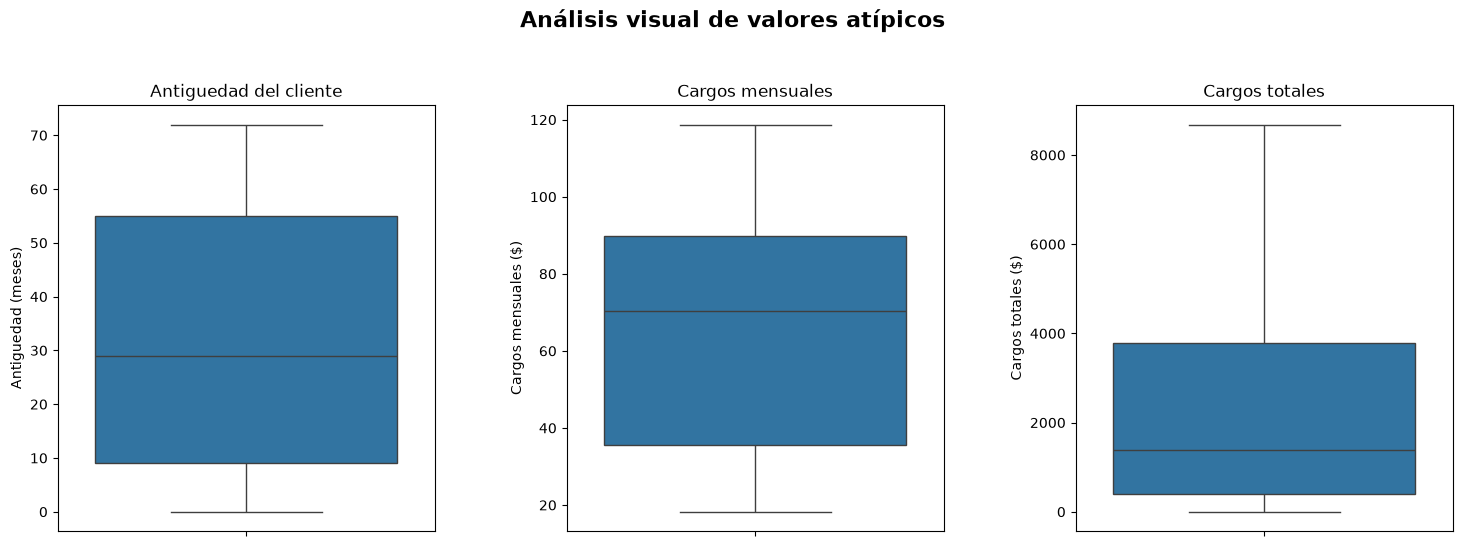

In [18]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antiguedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

#### Estadísticas básicas

In [19]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID_Hash", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [20]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

#### Selección de variables segmentadoras

In [21]:
numericas= ["tenure", "MonthlyCharges", "TotalCharges"]
categoricas = ["Partner", "Dependents", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "Contract", "PaperlessBilling", "PaymentMethod"]


# Limpieza y Transformación de Datos

# Modelo de segmentación KMeans (propuesta 1)

### Pipelines


In [22]:
pipeline_numeric = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5, weights="uniform")),
    ('scaler', StandardScaler())
])
pipeline_categorical = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
pipeline_preprocessor = ColumnTransformer([
    ("numeric", pipeline_numeric, numericas),
    ("categorical", pipeline_categorical, categoricas)
])

* Para las variables numericas utilizamos KNN ya que hay pocos registros con nulos y la existencia de correlacion entre las variables que pueden justificar su valor. StandardScaler para estandarizar la variables porque tienen magnitudes diferentes.

* Para las variables categoricas utilizamos SimpleImputer (a pesar de no haber nulos en categoricas) a pesar del riesgo de inflar o desproporcionar las distribuciones. OneHotEncoder ya que la variables cat. son nominales por tanto no tienen un orden jerarquico.

* Descartamos del preprocesador las variables Churn y customerID, porque no aportan al modelo y que churn es el objetivo y customerID es un identificador personal por registro.

In [23]:
X_crudo = df.drop([ 'Churn', 'customerID_Hash'], axis=1) 
matriz_limpia = pipeline_preprocessor.fit_transform(X_crudo)

if hasattr(matriz_limpia, "toarray"):
    matriz_limpia = matriz_limpia.toarray()

df_limpia = pd.DataFrame(
    matriz_limpia,
    columns=pipeline_preprocessor.get_feature_names_out()
)
df_limpia.head()

,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__Partner_No,categorical__Partner_Yes,categorical__Dependents_No,categorical__Dependents_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,...,categorical__TechSupport_Yes,categorical__Contract_Month-to-month,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_No,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check
0,-1.277445,-1.160323,-0.992611,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.066327,-0.259629,-0.172165,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.236724,-0.362660,-0.958066,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.514251,-0.746535,-0.193672,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,-1.236724,0.197365,-0.938874,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [24]:
df_limpia.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   numeric__tenure                                       7043 non-null   float64
 1   numeric__MonthlyCharges                               7043 non-null   float64
 2   numeric__TotalCharges                                 7043 non-null   float64
 3   categorical__Partner_No                               7043 non-null   float64
 4   categorical__Partner_Yes                              7043 non-null   float64
 5   categorical__Dependents_No                            7043 non-null   float64
 6   categorical__Dependents_Yes                           7043 non-null   float64
 7   categorical__InternetService_DSL                      7043 non-null   float64
 8   categorical__InternetService_Fiber optic              7043 non-null  

In [25]:
inercias = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_limpia)
    inercias.append(kmeans.inertia_)

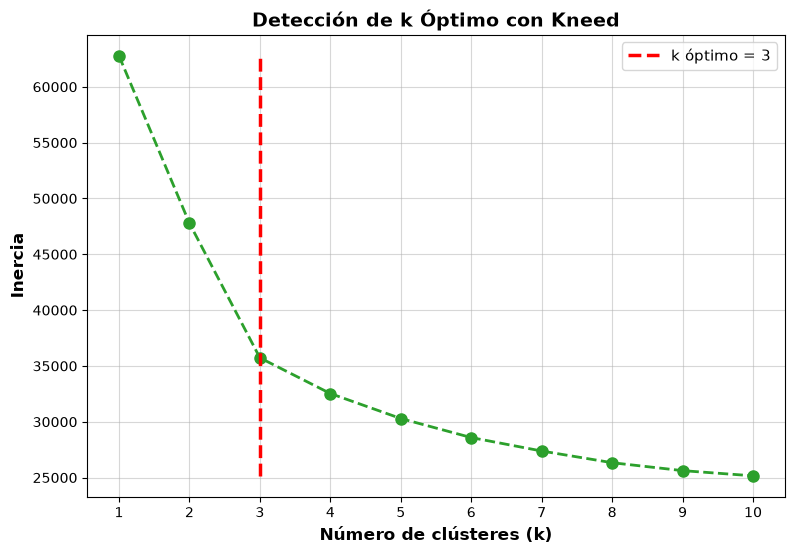

Número óptimo de clústeres: 3


In [26]:
kl = KneeLocator(rango_k, inercias, curve="convex", direction="decreasing")
k_optimo = kl.elbow
plt.figure(figsize=(9, 6))
plt.plot(rango_k, inercias, marker='o', linestyle='--', color='#2ca02c', linewidth=2, markersize=8)

plt.vlines(
    x=k_optimo,
    ymin=min(inercias),
    ymax=max(inercias),
    colors='red',
    linestyles='--',
    linewidth=2.5,
    label=f'k óptimo = {k_optimo}'
)

plt.title("Detección de k Óptimo con Kneed", fontsize=14, fontweight="bold")
plt.xlabel("Número de clústeres (k)", fontsize=12, fontweight="bold")
plt.ylabel("Inercia", fontsize=12, fontweight="bold")
plt.xticks(rango_k)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.5)
plt.show()

print(f"Número óptimo de clústeres: {k_optimo}")

In [27]:
kmeans_final = KMeans(n_clusters= k_optimo, random_state=42, n_init=10)
etiquetas_clusters = kmeans_final.fit_predict(df_limpia)
print(f"Inercia del modelo (k={k_optimo}): {kmeans_final.inertia_:.2f}")

Inercia del modelo (k=3): 35726.50


In [28]:
score = silhouette_score(df_limpia, etiquetas_clusters)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2816


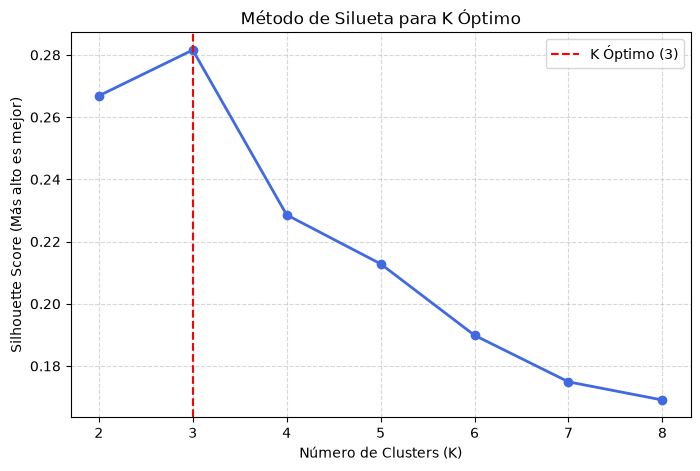

In [29]:
rango_k = range(2, 9)
scores = []

for k in rango_k:
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_temp = modelo_temp.fit_predict(df_limpia)
    score_temp = silhouette_score(df_limpia, etiquetas_temp)
    scores.append(score_temp)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, scores, marker='o', color='royalblue', linewidth=2)
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'K Óptimo ({k_optimo})')

plt.title('Método de Silueta para K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score (Más alto es mejor)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

* Bajo índice de silueta, por tanto se infiere solapamiento de los clusters y poca separación de los mismos.
* Inercia media-baja, por tanto se infiere un agrupamiento de cluster regular, ni tan bueno, ni tan malo. 

### PCA

In [30]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(df_limpia)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.32310975 0.22179248]


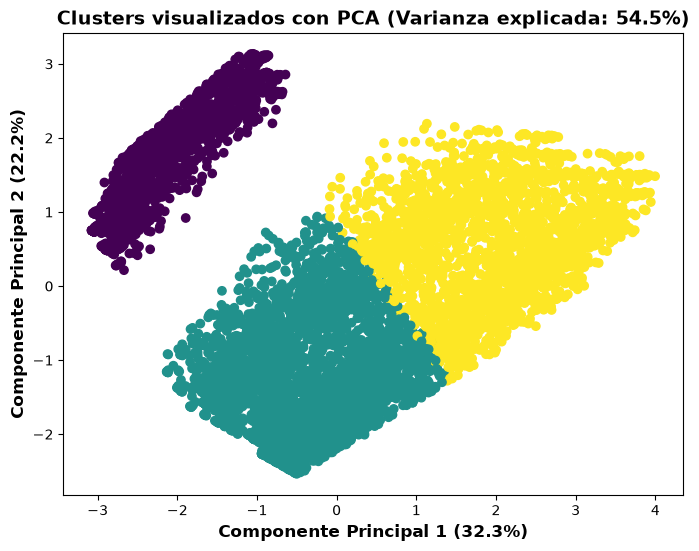

In [31]:
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_acumulada = var_pc1 + var_pc2

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=etiquetas_clusters,
    cmap="viridis"
)

plt.xlabel(f"Componente Principal 1 ({var_pc1:.1f}%)", fontsize=12, fontweight="bold")
plt.ylabel(f"Componente Principal 2 ({var_pc2:.1f}%)", fontsize=12, fontweight="bold")
plt.title(f"Clusters visualizados con PCA (Varianza explicada: {var_acumulada:.1f}%)", fontsize=14, fontweight="bold")

plt.show()

* Uso de PCA con varianza explicada del 54% aproximadamente, por tanto se infiere que al menos la mitad de información se refleja en el gráfico mediante sus componentes.
* Observaciones: 
    - Uno de los cluster bien separado y relativamente compacto.
    - Solapamiento claro en los otros dos cluster.

In [32]:
df_limpia["clusters"]= etiquetas_clusters

In [33]:
df_limpia[["clusters"]].value_counts().sort_index()

clusters
0           1526
1           3245
2           2272
Name: count, dtype: int64

## Aplicación al problema de negocio

### Porcentajes de abandono por cluster

Porcentaje de abandono (Churn) por Cluster:


Churn,No,Yes
clusters,,
0,92.6,7.4
1,55.5,44.5
2,86.3,13.7


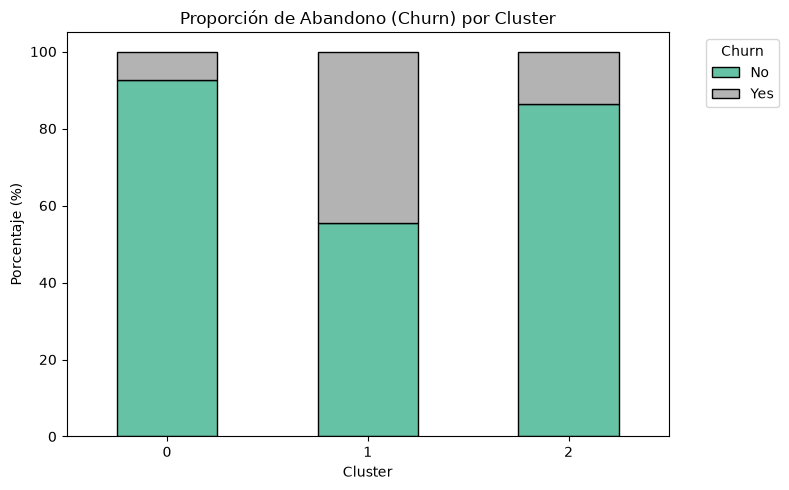

In [34]:
porcentaje_churn = pd.crosstab(df_limpia['clusters'], df['Churn'], normalize='index') * 100

print("Porcentaje de abandono (Churn) por Cluster:")
display(porcentaje_churn.round(1))

porcentaje_churn.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2', edgecolor='black')

plt.title('Proporción de Abandono (Churn) por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* Clusters 0 y 2 con bajo porcentaje de abandono
* Cluster 1 con un alto porcentaje de abandono, por tanto podría considerarse un candidato para fijación con estrategias de retención.

### Perfilamiento de los clusters

In [35]:
df["clusters"] = df_limpia["clusters"]
cols_numericas = df.select_dtypes(include=['float64', 'int32', 'int64']).columns.drop(['clusters', 'customerID_Hash'], errors='ignore')
cols_categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns.drop(['customerID_Hash','gender','Churn'], errors='ignore')
print("\nPERFIL NUMÉRICO")
perfil_num = df.groupby('clusters')[cols_numericas].mean().round(2)
display(perfil_num)
print("\nPERFIL CATEGÓRICO")
perfil_cat = df.groupby('clusters')[cols_categoricas].agg(lambda x: x.mode()[0] if not x.mode().empty else None)
display(perfil_cat)


PERFIL NUMÉRICO


,tenure,MonthlyCharges,TotalCharges
clusters,,,
0,30.55,21.08,662.60
1,15.26,69.09,1057.21
2,58.04,87.92,5111.97



PERFIL CATEGÓRICO


,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
clusters,,,,,,,,,,,,,,,
0,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
1,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
2,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)


* Cluster 0: Cliente análogo y de bajo impacto.
    - Usuarios de tecnología antigua, fidelizados con contratos estables, pero que no adoptan nuevas tecnologías.
* Cluster 1: Cliente Digitales de banda ancha y alto riesgo de fuga.
    - Usuarios de fibra óptica, pero no tienen lealtad a la marca ni consumen servicios extra.
* Cluster 2: Cliente Multi-Servicio y consolidado.
    - Usuarios que consumen la gama completa de servicios y están profundamente integrados en el ecosistema de la empresa.